# Predicting Match Outcomes in League of Legends Using Early-Game Team Statistics

This notebook analyzes early-game League of Legends team statistics to understand which factors are most associated with winning a match.


## Research question
Which early-game team statistics are most strongly associated with winning in League of Legends, and how accurately can match outcomes be predicted using these features?

## 1. Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [ ]:
file_path = "/content/match_data_v5_with_column.csv"

df = pd.read_csv(file_path)
print("Original shape:", df.shape)
df.head()

Original shape: (24225, 30)


,matchId,blueTeamControlWardsPlaced,blueTeamWardsPlaced,blueTeamTotalKills,blueTeamDragonKills,blueTeamHeraldKills,blueTeamTowersDestroyed,blueTeamInhibitorsDestroyed,blueTeamTurretPlatesDestroyed,blueTeamFirstBlood,blueTeamMinionsKilled,blueTeamJungleMinions,blueTeamTotalGold,blueTeamXp,blueTeamTotalDamageToChamps,redTeamControlWardsPlaced,redTeamWardsPlaced,redTeamTotalKills,redTeamDragonKills,redTeamHeraldKills,redTeamTowersDestroyed,redTeamInhibitorsDestroyed,redTeamTurretPlatesDestroyed,redTeamMinionsKilled,redTeamJungleMinions,redTeamTotalGold,redTeamXp,redTeamTotalDamageToChamps,blueWin,Unnamed: 29
0,EUW1_6882489515',2,23,4,2,0,0,0,7,0,388,106,23923,29798,21842,6,34,16,0,0,2,0,1,400,94,29637,32613,27239,1,NaN
1,EUW1_6882416210',2,46,12,1,0,1,0,10,0,348,98,27852,30530,35817,6,26,17,0,0,1,0,4,373,76,28970,30320,36585,0,NaN
2,EUW1_6881092720',2,19,13,0,0,0,0,11,0,331,96,28126,29501,38039,3,241,18,1,0,2,0,3,340,84,30510,29464,42984,0,NaN
3,EUW1_6879405717',3,28,8,0,1,1,0,9,1,355,84,27333,30466,31338,0,23,10,1,0,0,0,5,378,87,25157,31069,28229,0,NaN
4,EUW1_6879389461',3,30,11,1,1,1,0,7,0,370,100,27772,31066,26676,7,26,7,1,0,1,0,5,382,96,26052,29475,19245,1,NaN


## 2. Data Cleaning

`matchId` is not useful for prediction here, so we remove it.  
We also remove any empty unnamed columns.

In [ ]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", na=False)]

# Drop match id
if "matchId" in df.columns:
    df["matchId"] = df["matchId"].astype(str).str.replace("'", "", regex=False).str.strip()
    df = df.drop(columns=["matchId"])

print("Cleaned shape:", df.shape)
print(df.columns.tolist())

Cleaned shape: (24225, 28)
['blueTeamControlWardsPlaced', 'blueTeamWardsPlaced', 'blueTeamTotalKills', 'blueTeamDragonKills', 'blueTeamHeraldKills', 'blueTeamTowersDestroyed', 'blueTeamInhibitorsDestroyed', 'blueTeamTurretPlatesDestroyed', 'blueTeamFirstBlood', 'blueTeamMinionsKilled', 'blueTeamJungleMinions', 'blueTeamTotalGold', 'blueTeamXp', 'blueTeamTotalDamageToChamps', 'redTeamControlWardsPlaced', 'redTeamWardsPlaced', 'redTeamTotalKills', 'redTeamDragonKills', 'redTeamHeraldKills', 'redTeamTowersDestroyed', 'redTeamInhibitorsDestroyed', 'redTeamTurretPlatesDestroyed', 'redTeamMinionsKilled', 'redTeamJungleMinions', 'redTeamTotalGold', 'redTeamXp', 'redTeamTotalDamageToChamps', 'blueWin']


In [ ]:
# Basic quality checks
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nOutcome distribution:")
display(df["blueWin"].value_counts(dropna=False))
display(df["blueWin"].value_counts(normalize=True, dropna=False))

Duplicate rows: 7

Missing values by column:


,0
blueTeamControlWardsPlaced,0
blueTeamWardsPlaced,0
blueTeamTotalKills,0
blueTeamDragonKills,0
blueTeamHeraldKills,0
blueTeamTowersDestroyed,0
blueTeamInhibitorsDestroyed,0
blueTeamTurretPlatesDestroyed,0
blueTeamFirstBlood,0
blueTeamMinionsKilled,0



Outcome distribution:


,count
blueWin,
0,12245
1,11980


,proportion
blueWin,
0,0.50547
1,0.49453


## 3. Feature Engineering

These features describe early-game team performance:
- **Vision:** wards, control wards
- **Combat:** kills, first blood, damage to champions
- **Objectives:** dragon, herald, towers, inhibitors, turret plates
- **Economy and growth:** minions, jungle minions, gold, XP

Because this is a head-to-head game, the most useful features are often **blue team minus red team**. Therefore, we create difference features such that positive values mean a blue-side advantage.

In [ ]:
# Create difference features
df["controlWard_diff"] = df["blueTeamControlWardsPlaced"] - df["redTeamControlWardsPlaced"]
df["ward_diff"] = df["blueTeamWardsPlaced"] - df["redTeamWardsPlaced"]
df["kill_diff"] = df["blueTeamTotalKills"] - df["redTeamTotalKills"]
df["dragon_diff"] = df["blueTeamDragonKills"] - df["redTeamDragonKills"]
df["herald_diff"] = df["blueTeamHeraldKills"] - df["redTeamHeraldKills"]
df["tower_diff"] = df["blueTeamTowersDestroyed"] - df["redTeamTowersDestroyed"]
df["inhib_diff"] = df["blueTeamInhibitorsDestroyed"] - df["redTeamInhibitorsDestroyed"]
df["plate_diff"] = df["blueTeamTurretPlatesDestroyed"] - df["redTeamTurretPlatesDestroyed"]
df["minion_diff"] = df["blueTeamMinionsKilled"] - df["redTeamMinionsKilled"]
df["jungle_diff"] = df["blueTeamJungleMinions"] - df["redTeamJungleMinions"]
df["gold_diff"] = df["blueTeamTotalGold"] - df["redTeamTotalGold"]
df["xp_diff"] = df["blueTeamXp"] - df["redTeamXp"]
df["damage_diff"] = df["blueTeamTotalDamageToChamps"] - df["redTeamTotalDamageToChamps"]

diff_cols = [
    "controlWard_diff", "ward_diff", "kill_diff", "dragon_diff", "herald_diff",
    "tower_diff", "inhib_diff", "plate_diff", "minion_diff", "jungle_diff",
    "gold_diff", "xp_diff", "damage_diff", "blueTeamFirstBlood"
]

display(df[diff_cols + ["blueWin"]].head())

,controlWard_diff,ward_diff,kill_diff,dragon_diff,herald_diff,tower_diff,inhib_diff,plate_diff,minion_diff,jungle_diff,gold_diff,xp_diff,damage_diff,blueTeamFirstBlood,blueWin
0,-4,-11,-12,2,0,-2,0,6,-12,12,-5714,-2815,-5397,0,1
1,-4,20,-5,1,0,0,0,6,-25,22,-1118,210,-768,0,0
2,-1,-222,-5,-1,0,-2,0,8,-9,12,-2384,37,-4945,0,0
3,3,5,-2,-1,1,1,0,4,-23,-3,2176,-603,3109,1,0
4,-4,4,4,0,1,0,0,2,-12,4,1720,1591,7431,0,1


## 4. Exploratory Data Analysis
We first look at the summary of the statistics that we're interested in to get a general insights on the features.

In [ ]:
summary_cols = [
    "blueTeamTotalGold", "redTeamTotalGold",
    "blueTeamXp", "redTeamXp",
    "blueTeamTotalKills", "redTeamTotalKills",
    "gold_diff", "xp_diff", "kill_diff",
    "tower_diff", "dragon_diff", "damage_diff"
]

summary_table = df[summary_cols].describe().T
display(summary_table)

,count,mean,std,min,25%,50%,75%,max
blueTeamTotalGold,24225.0,27831.717771,2740.935799,17719.0,25912.0,27675.0,29574.0,40968.0
redTeamTotalGold,24225.0,27788.709391,2694.330794,18247.0,25910.0,27629.0,29514.0,41227.0
blueTeamXp,24225.0,29572.765119,1879.301846,19061.0,28341.0,29584.0,30836.0,36801.0
redTeamXp,24225.0,29619.035789,1896.275564,17602.0,28387.0,29632.0,30866.0,36797.0
blueTeamTotalKills,24225.0,12.792487,4.910510,0.0,9.0,12.0,16.0,38.0
redTeamTotalKills,24225.0,12.863529,4.850884,0.0,9.0,13.0,16.0,37.0
gold_diff,24225.0,43.008380,4367.800386,-17787.0,-2821.0,30.0,2917.0,20282.0
xp_diff,24225.0,-46.270671,3089.772283,-14189.0,-2092.0,-58.0,1978.0,13480.0
kill_diff,24225.0,-0.071042,7.131956,-31.0,-5.0,0.0,5.0,31.0
tower_diff,24225.0,-0.300186,1.464421,-10.0,-1.0,0.0,1.0,10.0


In [ ]:
group_means = df.groupby("blueWin")[[
    "gold_diff", "xp_diff", "kill_diff", "tower_diff",
    "dragon_diff", "herald_diff", "plate_diff",
    "damage_diff", "ward_diff", "controlWard_diff"
]].mean()

group_means.index = ["Blue Loss", "Blue Win"]
display(group_means)

,gold_diff,xp_diff,kill_diff,tower_diff,dragon_diff,herald_diff,plate_diff,damage_diff,ward_diff,controlWard_diff
Blue Loss,-2384.793303,-1693.817477,-3.813393,-0.836995,-0.622621,-0.049816,6.668518,-3443.171825,-2.361535,-0.258718
Blue Win,2524.513523,1637.720200,3.754090,0.248497,0.297078,0.092321,3.358765,3553.133222,-1.729299,0.198748


The plots below compare the distributions of key features by match outcome.

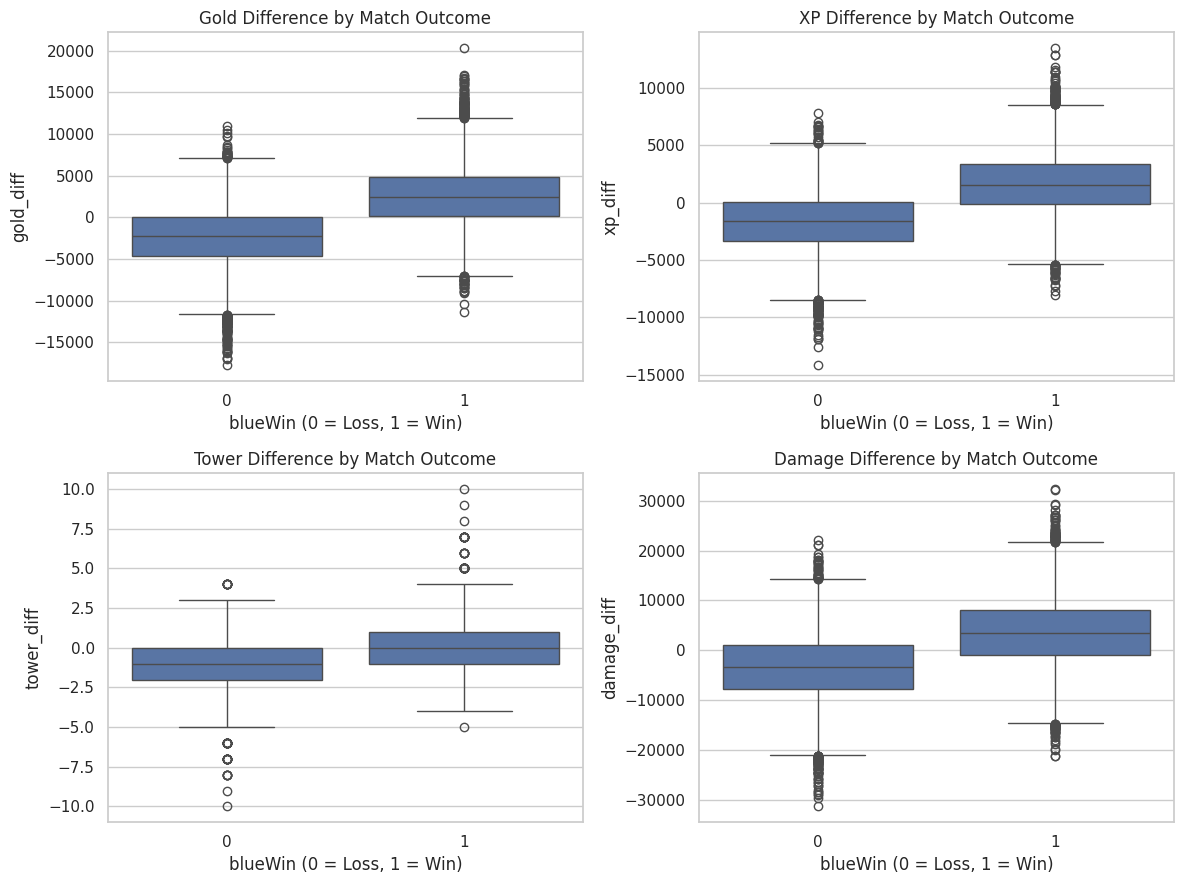

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=df, x="blueWin", y="gold_diff", ax=axes[0, 0])
axes[0, 0].set_title("Gold Difference by Match Outcome")

sns.boxplot(data=df, x="blueWin", y="xp_diff", ax=axes[0, 1])
axes[0, 1].set_title("XP Difference by Match Outcome")

sns.boxplot(data=df, x="blueWin", y="tower_diff", ax=axes[1, 0])
axes[1, 0].set_title("Tower Difference by Match Outcome")

sns.boxplot(data=df, x="blueWin", y="damage_diff", ax=axes[1, 1])
axes[1, 1].set_title("Damage Difference by Match Outcome")

for ax in axes.flat:
    ax.set_xlabel("blueWin (0 = Loss, 1 = Win)")

plt.tight_layout()
plt.show()

The boxplots reveal a clear and consistent separation between wins and losses across all features. For gold, XP, damage, and tower differences, matches resulting in a win (blueWin = 1) generally have positive median values, while losses show negative medians. This indicates that winning teams tend to accumulate more resources (gold), gain more experience (XP), deal more damage, and secure more objectives (towers) than their opponents. Among these, damage and gold differences show particularly strong separation, suggesting a dominant role of combat effectiveness and economic advantage in determining outcomes. Although there is some overlap in the distributions, the overall pattern suggests that these variables are strong predictors of match results and can be effectively used in predictive modeling.

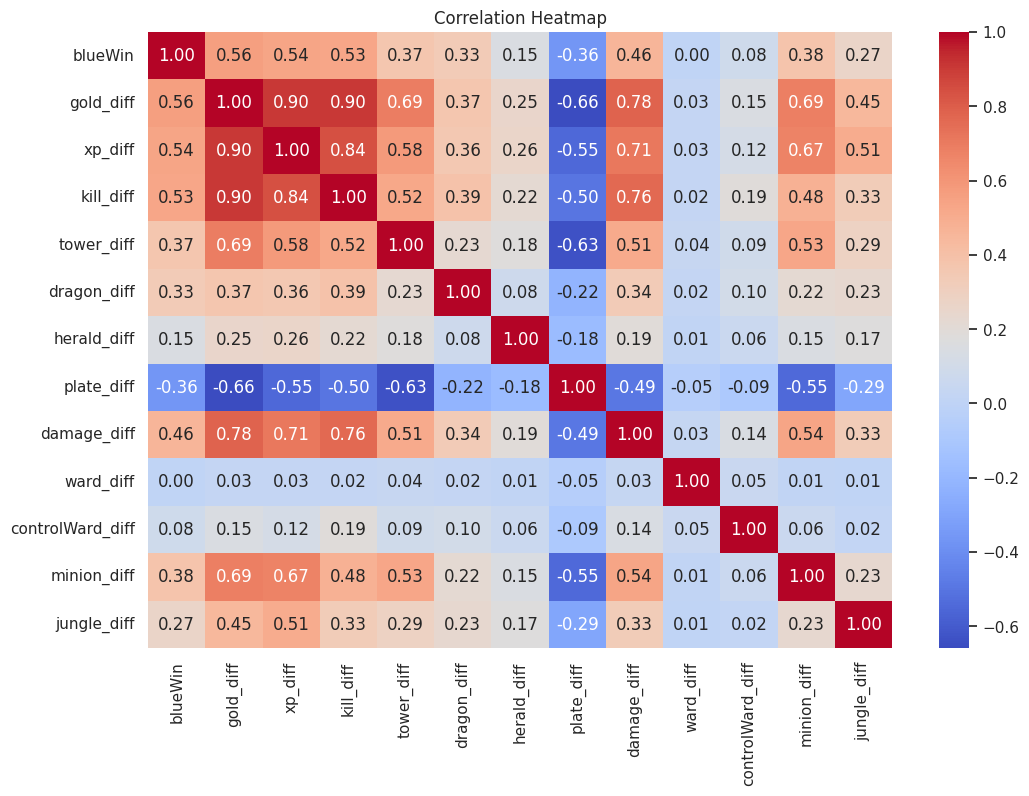

In [ ]:
plt.figure(figsize=(12, 8))
corr_cols = [
    "blueWin", "gold_diff", "xp_diff", "kill_diff", "tower_diff",
    "dragon_diff", "herald_diff", "plate_diff", "damage_diff",
    "ward_diff", "controlWard_diff", "minion_diff", "jungle_diff"
]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows a clear cluster of strong positive correlations among gold, XP, and kill differences, indicating high collinearity between these features. This is expected, as in-game actions like farming and securing kills simultaneously generate gold and XP, which in turn strengthen champions and enable further kills and objective control (e.g., towers). Additionally, damage and minion differences are moderately correlated with these core features, reinforcing the idea that resource and combat advantages are closely linked. An interesting pattern is that plate difference is negatively correlated with most variables, including match outcome. Since turret plates provide gold to the opposing team when destroyed, a lower plate difference (i.e., losing more plates) reflects giving away resources, which aligns with a lower probability of winning.

## 5. Modeling setup
The data is split into train and test set where only train data is used for modeling (80/20 split).

In [ ]:
feature_cols = [
    "controlWard_diff",
    "ward_diff",
    "kill_diff",
    "dragon_diff",
    "herald_diff",
    "tower_diff",
    "inhib_diff",
    "plate_diff",
    "minion_diff",
    "jungle_diff",
    "gold_diff",
    "xp_diff",
    "damage_diff",
    "blueTeamFirstBlood"
]

X = df[feature_cols]
y = df["blueWin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (19380, 14)
Test shape: (4845, 14)


## 6. Logistic Regression

In [ ]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_model.fit(X_train, y_train)

y_pred_logit = logit_model.predict(X_test)
y_prob_logit = logit_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_logit), 4))
print("Logistic Regression AUC:", round(roc_auc_score(y_test, y_prob_logit), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logit))

Logistic Regression Accuracy: 0.7641
Logistic Regression AUC: 0.845

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2449
           1       0.77      0.75      0.76      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845



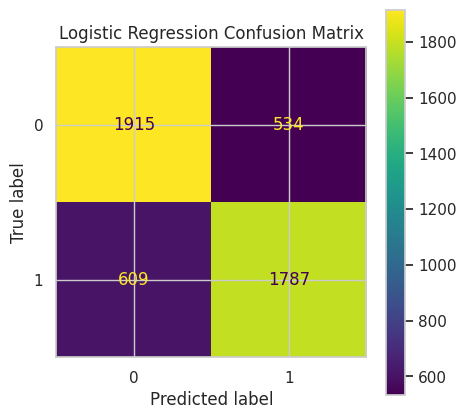

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logit, ax=ax)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

The logistic regression model shows solid and well-balanced performance, with an overall accuracy of 76.4% and an AUC of 0.845, indicating good ability to distinguish between the two classes. The confusion matrix and classification report suggest that the model performs similarly across both classes, with precision and recall values around 0.75–0.78. This balance implies that the model does not systematically favor one class over the other, and both types of misclassification (false positives and false negatives) occur at comparable rates. Overall, the model provides a reliable baseline with consistent predictive performance, though there is still moderate room for improvement in reducing classification errors.

In [ ]:
logit = logit_model.named_steps["logit"]
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logit.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df)

,feature,coefficient
10,gold_diff,1.004531
11,xp_diff,0.473627
3,dragon_diff,0.377821
2,kill_diff,0.148521
6,inhib_diff,0.110949
12,damage_diff,0.077623
5,tower_diff,0.021809
4,herald_diff,0.007399
9,jungle_diff,-0.009855
0,controlWard_diff,-0.020156


### Interpretation:
The logistic regression coefficients indicate that gold_diff is the most influential predictor, followed by xp_diff and dragon_diff, suggesting that overall resource advantage and major objective control are the strongest drivers of winning. Combat-related features such as kill_diff and damage_diff also contribute positively, but their effects are smaller once gold and experience are accounted for, which is consistent with their indirect impact through resource accumulation. Structural objectives like tower_diff and inhib_diff have relatively modest positive effects. Interestingly, features such as plate_diff, ward_diff, and minion_diff have small negative coefficients, likely reflecting multicollinearity with stronger variables like gold and xp, rather than true negative impact. Overall, the model emphasizes that macro-level advantages (especially gold and experience) dominate outcome prediction, while other features provide incremental information.

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# Regularized Logistic Regression with cross-validation
# Try L1, L2, and Elastic Net regularization
regularized_models = {
    "Ridge Logistic (L2)": LogisticRegressionCV(
        Cs=np.logspace(-3, 3, 20),
        penalty="l2",
        solver="lbfgs",
        cv=5,
        scoring="roc_auc",
        max_iter=5000
    ),

    "Lasso Logistic (L1)": LogisticRegressionCV(
        Cs=np.logspace(-3, 3, 20),
        penalty="l1",
        solver="saga",
        cv=5,
        scoring="roc_auc",
        max_iter=5000
    ),

    "Elastic Net Logistic": LogisticRegressionCV(
        Cs=np.logspace(-3, 3, 20),
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.2, 0.5, 0.8],
        cv=5,
        scoring="roc_auc",
        max_iter=5000
    )
}

results = []

for name, model in regularized_models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "model": name,
        "accuracy": acc,
        "auc": auc
    })

    print("\n" + name)
    print("Accuracy:", round(acc, 4))
    print("AUC:", round(auc, 4))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
results_df


Ridge Logistic (L2)
Accuracy: 0.7641
AUC: 0.845
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2449
           1       0.77      0.75      0.76      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845


Lasso Logistic (L1)
Accuracy: 0.7626
AUC: 0.8447
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2449
           1       0.77      0.75      0.76      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845


Elastic Net Logistic
Accuracy: 0.7626
AUC: 0.8445
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2449
           1       0.77      0.75      0.76      2396

    accuracy                    

,model,accuracy,auc
0,Ridge Logistic (L2),0.764087,0.844999
1,Lasso Logistic (L1),0.762642,0.844722
2,Elastic Net Logistic,0.762642,0.844549


The regularized logistic regression models (Ridge, Lasso, and Elastic Net) show nearly identical performance to the baseline model, with accuracy around 0.76 and AUC around 0.845. This suggests that regularization does not materially improve predictive performance in this case. A likely reason is that, although there is multicollinearity among features, it does not significantly harm the model’s ability to predict outcomes. Instead, regularization primarily helps stabilize coefficient estimates rather than boost accuracy or AUC. As a result, the model is already operating near its optimal predictive capacity given the current feature set.

## 7. Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Random Forest AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7595
Random Forest AUC: 0.8384

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      2449
           1       0.77      0.73      0.75      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845



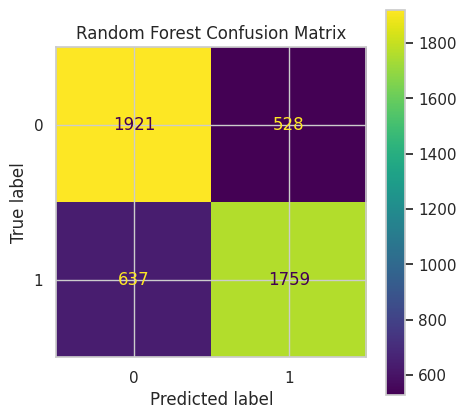

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

,feature,importance
10,gold_diff,2.090998e-01
11,xp_diff,1.685309e-01
2,kill_diff,1.161050e-01
12,damage_diff,1.067220e-01
8,minion_diff,7.771408e-02
9,jungle_diff,6.408792e-02
1,ward_diff,6.035748e-02
7,plate_diff,5.606115e-02
3,dragon_diff,4.513175e-02
0,controlWard_diff,4.146861e-02


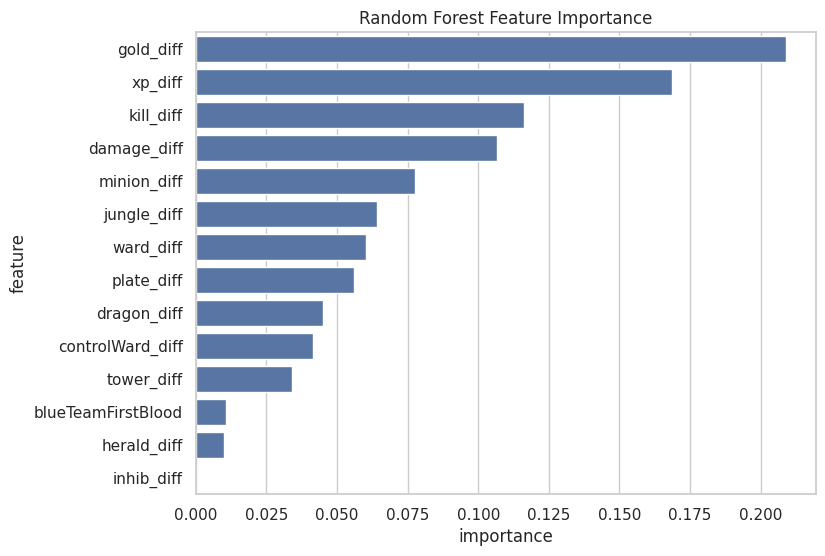

In [ ]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.show()

The Random Forest model achieves an accuracy of about 0.76 and an AUC of 0.84, indicating solid overall classification performance and good ability to distinguish between the two classes. Precision and recall are fairly balanced across classes, though the model performs slightly better at identifying class 0 (higher recall) than class 1. The similar F1-scores (~0.75–0.77) suggest no major class imbalance issues in prediction quality. From the feature importance, gold_diff and xp_diff are the most influential predictors, followed by kill_diff and damage_diff, highlighting that economic and combat advantages are the primary drivers of outcomes.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# prediction
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# evaluation
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Accuracy:", round(xgb_acc, 4))
print("XGBoost AUC:", round(xgb_auc, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# feature importance
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

xgb_importance

XGBoost Accuracy: 0.76
XGBoost AUC: 0.8428

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      2449
           1       0.77      0.73      0.75      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845



,feature,importance
10,gold_diff,0.495158
2,kill_diff,0.134427
11,xp_diff,0.121081
3,dragon_diff,0.072027
12,damage_diff,0.023824
5,tower_diff,0.022642
8,minion_diff,0.021679
7,plate_diff,0.020695
0,controlWard_diff,0.019049
9,jungle_diff,0.018812


While XGBoost slightly improves accuracy compared to Random Forest, the gain is marginal, suggesting that model performance is primarily limited by the available features rather than model complexity. We further experimented with tuning various hyperparameters, including learning rate, max depth, and number of estimators, but observed minimal impact on performance. This indicates that the model has likely reached a performance ceiling given the current feature set. Therefore, further improvements are more likely to come from feature engineering rather than additional hyperparameter tuning.

In [ ]:
def safe_ratio(blue, red):
    denom = blue + red
    return np.where(denom == 0, 0.5, blue / denom)

df["gold_ratio"] = safe_ratio(df["blueTeamTotalGold"], df["redTeamTotalGold"])
df["xp_ratio"] = safe_ratio(df["blueTeamXp"], df["redTeamXp"])
df["kill_ratio"] = safe_ratio(df["blueTeamTotalKills"], df["redTeamTotalKills"])
df["damage_ratio"] = safe_ratio(
    df["blueTeamTotalDamageToChamps"],
    df["redTeamTotalDamageToChamps"]
)

features = [
    "controlWard_diff", "ward_diff", "kill_diff", "dragon_diff",
    "herald_diff", "tower_diff", "inhib_diff", "plate_diff",
    "minion_diff", "jungle_diff", "gold_diff", "xp_diff",
    "damage_diff", "blueTeamFirstBlood",

    # new ratio features
    "gold_ratio", "xp_ratio", "kill_ratio", "damage_ratio"
]

X = df[features]
y = df["blueWin"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model2.fit(X_train, y_train)

y_pred = xgb_model2.predict(X_test)
y_prob = xgb_model2.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.7578947368421053
XGBoost AUC: 0.8389935144391325
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      2449
           1       0.77      0.73      0.75      2396

    accuracy                           0.76      4845
   macro avg       0.76      0.76      0.76      4845
weighted avg       0.76      0.76      0.76      4845



In [ ]:
# feature importance
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model2.feature_importances_
}).sort_values(by="importance", ascending=False)

xgb_importance

,feature,importance
10,gold_diff,0.283981
14,gold_ratio,0.240958
15,xp_ratio,0.090617
3,dragon_diff,0.067077
2,kill_diff,0.047763
11,xp_diff,0.047125
16,kill_ratio,0.024848
17,damage_ratio,0.021777
13,blueTeamFirstBlood,0.020523
0,controlWard_diff,0.020436


We observe that both difference-based and ratio-based features yield similar predictive performance, indicating that they capture largely overlapping information. This suggests that model performance is more constrained by the intrinsic information in the data rather than feature representation. Therefore, further improvements are more likely to come from introducing new sources of information.

## 8. Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve

# Start with models that already have saved predictions
comparison_results = []

model_outputs = {
    "Logistic Regression": (y_pred_logit, y_prob_logit),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb),
    "Tuned XGBoost": (y_pred, y_prob)
}

for model_name, (y_pred_model, y_prob_model) in model_outputs.items():
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "AUC": roc_auc_score(y_test, y_prob_model),
        "Precision": precision_score(y_test, y_pred_model),
        "Recall": recall_score(y_test, y_pred_model),
        "F1-score": f1_score(y_test, y_pred_model)
    })

# Add regularized logistic results from results_df
regularized_results = results_df.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "auc": "AUC"
})

regularized_results["Precision"] = np.nan
regularized_results["Recall"] = np.nan
regularized_results["F1-score"] = np.nan

comparison_df = pd.concat(
    [pd.DataFrame(comparison_results), regularized_results],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(by="AUC", ascending=False).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Accuracy,AUC,Precision,Recall,F1-score
0,Ridge Logistic (L2),0.7641,0.8450,NaN,NaN,NaN
1,Logistic Regression,0.7641,0.8450,0.7699,0.7458,0.7577
2,Lasso Logistic (L1),0.7626,0.8447,NaN,NaN,NaN
3,Elastic Net Logistic,0.7626,0.8445,NaN,NaN,NaN
4,XGBoost,0.7600,0.8428,0.7705,0.7329,0.7512
5,Tuned XGBoost,0.7579,0.8390,0.7705,0.7270,0.7481
6,Random Forest,0.7595,0.8384,0.7691,0.7341,0.7512


The model comparison shows that logistic regression–based models perform the best overall, with Ridge Logistic Regression and standard logistic regression achieving the highest AUC (0.845) and accuracy (0.764). The Lasso Logistic Regression and Elastic Net Logistic Regression perform nearly identically, suggesting that regularization does not substantially change predictive power, likely due to feature collinearity already being manageable. In contrast, tree-based models such as XGBoost and Random Forest show slightly lower AUC and accuracy, indicating that additional nonlinear flexibility does not provide a meaningful performance gain. Overall, this suggests that the underlying relationship is relatively linear, and the simpler logistic regression model is sufficient while offering better interpretability.

## 9. Interpretation

### Key findings
- Early-game advantages in **gold**, **experience**, and **objective control** appear strongly associated with winning.
- Structural pressure, especially **towers** and **turret plates**, may matter as much as or more than raw kills.
- Vision metrics such as **wards** and **control wards** may contribute indirectly by enabling safer map control and objective setups.

### Conclusion
This study investigates whether early-game team statistics can effectively predict match outcomes in League of Legends. By constructing difference-based features that capture the relative advantage between teams, we find that economic and combat-related variables—particularly gold difference, experience difference, and damage dealt—are the most influential predictors of match results.

Across all models, including logistic regression, random forest, and XGBoost, predictive performance is consistently strong, with accuracy around 76% and AUC around 0.84–0.85. Notably, more complex models such as XGBoost do not significantly outperform logistic regression, suggesting that the relationship between features and outcomes is largely captured by relatively simple linear structures.

Additionally, although there is clear multicollinearity among key features (e.g., gold, XP, and kills), regularization techniques (L1, L2, Elastic Net) do not substantially improve predictive performance, indicating that collinearity does not severely harm model generalization in this setting.

Further experiments with ratio-based features yield similar results, implying that the model performance is primarily constrained by the information content of the data rather than feature representation or model complexity.

### Limitation

While the model demonstrates strong predictive performance, its practical use is best suited for descriptive and analytical purposes rather than direct decision-making. Specifically, the results provide a useful reference for audiences watching professional matches, as they highlight how early-game advantages—such as gold, XP, and damage—are strongly associated with winning outcomes.

However, when it comes to coaching decisions or training strategies, these findings should be interpreted with caution. The analysis is fundamentally based on associations rather than causal relationships, meaning that the model identifies patterns but does not establish whether improving a specific metric will directly lead to winning. Additionally, many important factors are not captured in the dataset, such as player skill, team coordination, draft strategy, and real-time decision-making.

Therefore, while the model can support game understanding and post-game analysis, it should not be used as a standalone tool for strategic decision-making.